# CFPB Fraud Intelligence — Milestone 5 Final Evaluation (Colab)

This notebook runs the final reproducible experiment for the capstone:

1. clone the GitHub repository;
2. install the final dependencies;
3. verify the end-to-end pipeline;
4. compare a simple baseline prompt with the structured fraud-intelligence prompt;
5. calculate automatic grounding metrics;
6. create report-ready figures and a human-evaluation template.

**Recommended runtime:** T4 GPU.


In [123]:
REPO_URL = "https://github.com/michaelbimo/Milestone-5-Final-Project-Submission.git"
BRANCH = "main"
PROJECT_FOLDER = "Milestone-5-Final-Project-Submission"
NUM_EVAL_SAMPLES = 30


In [124]:
%cd /content

/content


In [125]:
!git ls-remote "https://github.com/michaelbimo/Milestone-5-Final-Project-Submission.git"

f054bb39780ae952d44ec0a4d70967779d255da9	HEAD
f054bb39780ae952d44ec0a4d70967779d255da9	refs/heads/main


## 1. Clone a clean copy of the repository

A clean clone makes the final evaluation reproducible and avoids depending on files left over from an earlier Colab session.

In [126]:
from pathlib import Path
import os, shutil, subprocess

PROJECT_FOLDER = "Milestone-5-Final-Project-Submission"

project_dir = Path("/content") / PROJECT_FOLDER
if project_dir.exists():
    shutil.rmtree(project_dir)

subprocess.run(["git", "clone", "--branch", BRANCH, REPO_URL, str(project_dir)], check=True)
os.chdir(project_dir)
print("Working directory:", Path.cwd())

Working directory: /content/Milestone-5-Final-Project-Submission


## 2. Install dependencies and confirm the runtime

In [127]:
%pip install -q -r requirements.txt


In [128]:
import torch
print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("The experiment can run on CPU, but a T4 GPU is recommended.")


PyTorch: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


## 3. Verify the required single-command pipeline

This is the same requirement demonstrated in Milestone 4. It should create the representative samples in `outputs/`.

In [136]:
!python src/model_runner.py


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 282/282 [00:00<00:00, 895.75it/s] 
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
Loaded 25,576 preprocessed complaints.
Selected 10 representative samples.
Generated samples saved to: /content/Milestone-5-Final-Project-Submission/outputs/samples.txt
{
  "non_empty_output_rate": 1.0,
  "average_summary_words": 31.1,
  "risk_level_mention_rate": 0.0
}


In [137]:
from pathlib import Path

for path in sorted(Path("outputs").glob("*")):
    if path.is_file():
        print(f"{path}: {path.stat().st_size:,} bytes")


outputs/README.md: 638 bytes
outputs/output_description.md: 527 bytes
outputs/prepared_inputs.jsonl: 23,277 bytes
outputs/run_metadata.json: 451 bytes
outputs/samples.jsonl: 25,317 bytes
outputs/samples.txt: 5,679 bytes


## 4. Run the Milestone 5 experiment

The experiment uses the **same deterministic sample, model, seed, and decoding settings** for both conditions:

- `baseline`: simple complaint summarization prompt;
- `structured`: complaint + provisional archetype + red flags + risk level.

This makes the prompt comparison easier to interpret.

In [163]:
!python src/experiment_runner.py --num-samples {NUM_EVAL_SAMPLES}


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 190/190 [00:00<00:00, 1526.67it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
Saved baseline experiment: /content/Milestone-5-Final-Project-Submission/results/experiments/baseline_prompt.jsonl
Loading weights: 100% 190/190 [00:00<00:00, 1431.33it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
Saved structured experiment: /content/Milestone-5-Final-Project-Submission/results/experiments/structured_prompt.jsonl
{
  "

## 5. Evaluate the generated summaries

In [158]:
!python src/evaluate.py


Preserving existing final human-review template:
/content/Milestone-5-Final-Project-Submission/results/human_evaluation_final_template.csv
/content/Milestone-5-Final-Project-Submission/src/evaluate.py:909: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(

FINAL EVALUATION SUMMARY

Automatic comparison:
  evaluation_variant prompt_style  samples  non_empty_output_rate  average_summary_words  risk_level_mention_rate  mean_red_flag_coverage  mean_archetype_keyword_coverage  mean_unsupported_number_rate  mean_source_token_support
        baseline_raw     baseline       30                    1.0              16.366667                      0.0                0.483333                         0.103889                           0.0                   0.801471
      structured_raw   structured       30                    1.0              13.333333                  

In [173]:
import pandas as pd

comparison = pd.read_csv("results/model_comparison.csv")
display(comparison)


,evaluation_variant,prompt_style,samples,non_empty_output_rate,average_summary_words,risk_level_mention_rate,mean_red_flag_coverage,mean_archetype_keyword_coverage,mean_unsupported_number_rate,mean_source_token_support
0,baseline_raw,baseline,30,1.0,16.366667,0.0,0.483333,0.103889,0.0,0.801471
1,structured_raw,structured,30,1.0,13.333333,0.0,0.450000,0.078889,0.0,0.650501
2,baseline_validated,baseline,30,1.0,24.566667,0.0,0.483333,0.126111,0.0,0.851471
3,structured_validated,structured,30,1.0,28.366667,0.0,0.483333,0.128889,0.0,0.942168


## 6. Display report-ready figures

results/figures/prompt_comparison_metrics.png


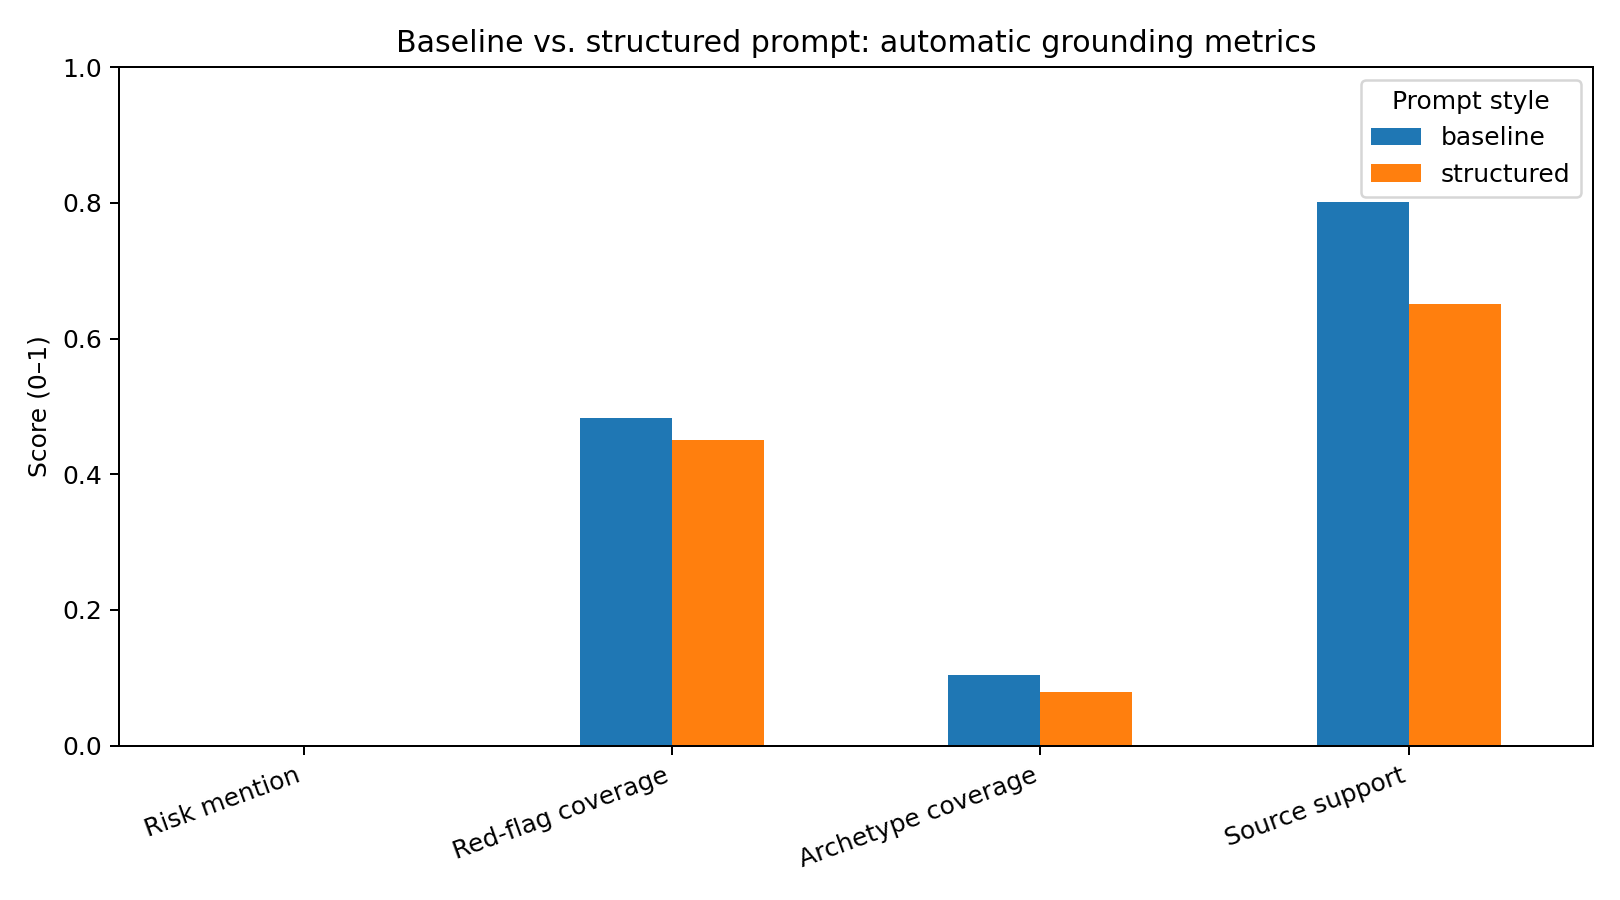

results/figures/summary_length_distribution.png


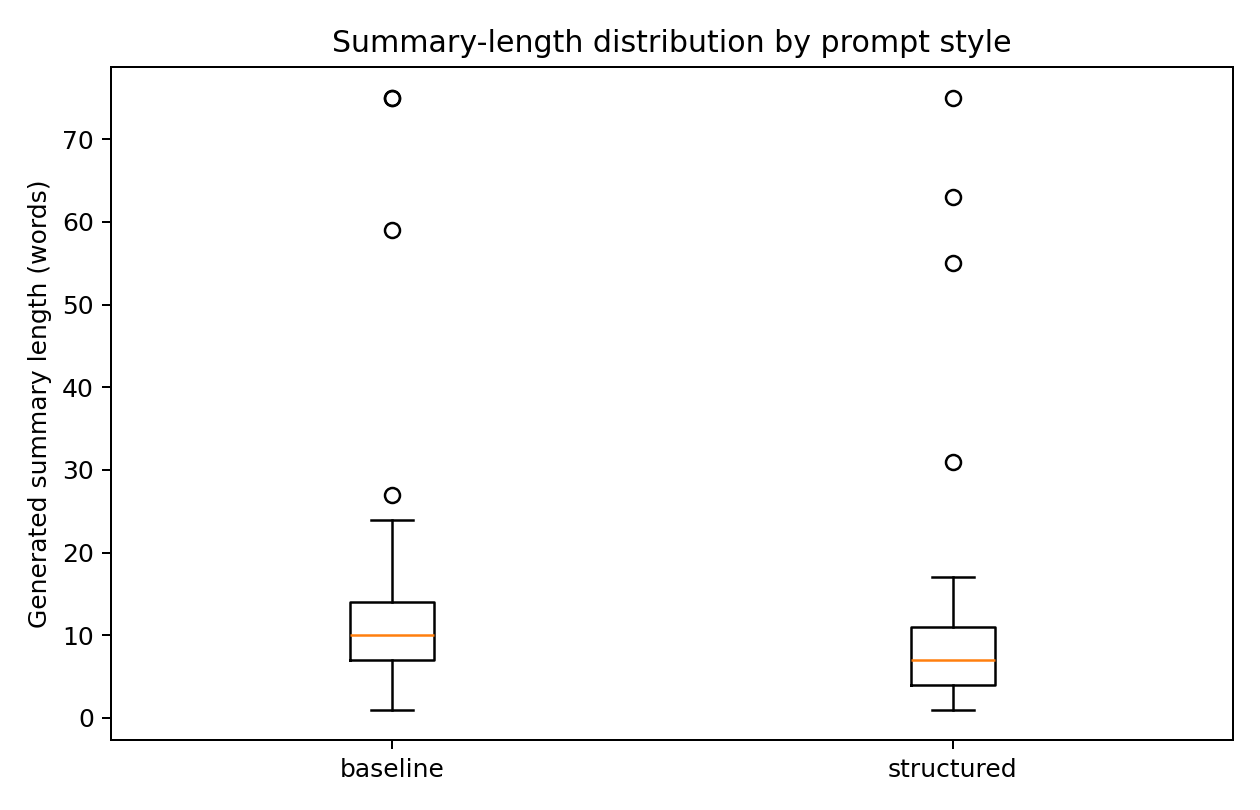

In [174]:
from IPython.display import Image, display

for figure in [
    "results/figures/prompt_comparison_metrics.png",
    "results/figures/summary_length_distribution.png",
]:
    print(figure)
    display(Image(filename=figure))


## 7. Human evaluation

Download `results/human_evaluation_template.csv` and rate a reasonable subset of outputs from **1–5** for factuality, relevance, clarity, and analyst usefulness.

After filling the ratings, replace the CSV in the repository/runtime and rerun:

```bash
python src/evaluate.py
```

The evaluator will automatically add the human-score averages to the final metrics when ratings are present.

## 8. Package the generated results for GitHub

Colab does **not** automatically push generated files back to GitHub. The safest workflow is to download the small final results ZIP, copy its contents into your local GitHub Desktop repository, then commit and push.

In [175]:
import shutil
from pathlib import Path

archive_base = "/content/milestone5_results"
archive = shutil.make_archive(archive_base, "zip", root_dir=Path.cwd(), base_dir="results")
print("Download this file from the Colab Files panel:", archive)


Download this file from the Colab Files panel: /content/milestone5_results.zip


In [171]:
%cd /content/Milestone-5-Final-Project-Submission

!python src/evaluate.py --config configs/final_eval_config.yaml

/content
Preserving existing final human-review template:
/content/Milestone-5-Final-Project-Submission/results/final_test/human_evaluation_final_template.csv
/content/Milestone-5-Final-Project-Submission/src/evaluate.py:909: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(

FINAL EVALUATION SUMMARY

Automatic comparison:
  evaluation_variant prompt_style  samples  non_empty_output_rate  average_summary_words  risk_level_mention_rate  mean_red_flag_coverage  mean_archetype_keyword_coverage  mean_unsupported_number_rate  mean_source_token_support
        baseline_raw     baseline       30                    1.0              16.766667                      0.0                0.766667                         0.022222                           0.0                   0.808889
      structured_raw   structured       30                    1.0              15.4666

### Recommended GitHub commit sequence

After copying the Milestone 5 code into the local repository, commit the code first:

```text
Add Milestone 5 evaluation pipeline
```

After the Colab experiment finishes and you copy the final `results/` files into the local repository, make a second commit:

```text
Add final prompt comparison results and figures
```

This gives the final repository a clear, professional history.